## 1. Install Libraries

In [3]:
!pip install -q nibabel tqdm matplotlib kagglehub surface-distance scikit-image plotly pandas segmentation-models-pytorch timm opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.7 MB/s eta 0:00:00


## 2. Download Dataset

In [4]:
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("muhammedkerem/brain-hemorrhage-segmentation-3d-data")
print("Dataset path:", path)

root = Path(path) / "Dataset" / "nifti_files_last_data" / "nifti_files_last_data"

train_img_dir = root / "TrainVolumes"
train_lab_dir = root / "TrainSegmentation"
test_img_dir  = root / "TestVolumes"
test_lab_dir  = root / "TestSegmentation"

print("Root:", root)
print("TrainVolumes exists:", train_img_dir.exists())
print("TrainSegmentation exists:", train_lab_dir.exists())
print("TestVolumes exists:", test_img_dir.exists())
print("TestSegmentation exists:", test_lab_dir.exists())

100%|██████████| 1.71G/1.71G [00:17<00:00, 107MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/muhammedkerem/brain-hemorrhage-segmentation-3d-data/versions/1
Root: /root/.cache/kagglehub/datasets/muhammedkerem/brain-hemorrhage-segmentation-3d-data/versions/1/Dataset/nifti_files_last_data/nifti_files_last_data
TrainVolumes exists: True
TrainSegmentation exists: True
TestVolumes exists: True
TestSegmentation exists: True


## 3. Build Train/Test Pairs

In [ ]:
def make_pairs(img_dir, lab_dir):
    imgs = sorted(img_dir.glob("*.nii"))
    labs = {p.name: p for p in lab_dir.glob("*.nii")}
    pairs = []
    for img in imgs:
        if img.name in labs:
            pairs.append({
                "image": str(img),
                "label": str(labs[img.name]),
                "name": img.name,
            })
    return pairs

train_pairs = make_pairs(train_img_dir, train_lab_dir)
test_pairs  = make_pairs(test_img_dir, test_lab_dir)

print(f"Train volumes: {len(train_pairs)}")
print(f"Test volumes : {len(test_pairs)}")
print("Example:", train_pairs[0])

Train volumes: 215
Test volumes : 50
Example: {'image': '/root/.cache/kagglehub/datasets/muhammedkerem/brain-hemorrhage-segmentation-3d-data/versions/1/Dataset/nifti_files_last_data/nifti_files_last_data/TrainVolumes/cerebral_0_0_0.nii', 'label': '/root/.cache/kagglehub/datasets/muhammedkerem/brain-hemorrhage-segmentation-3d-data/versions/1/Dataset/nifti_files_last_data/nifti_files_last_data/TrainSegmentation/cerebral_0_0_0.nii', 'name': 'cerebral_0_0_0.nii'}


## 4. check Label Values & Visualize

In [6]:
import nibabel as nib
import numpy as np

sample_lab = nib.load(train_pairs[0]["label"]).get_fdata()
print("Unique label values:", np.unique(sample_lab))
print("Shape:", sample_lab.shape)

Unique label values: [0. 1.]
Shape: (512, 512, 23)


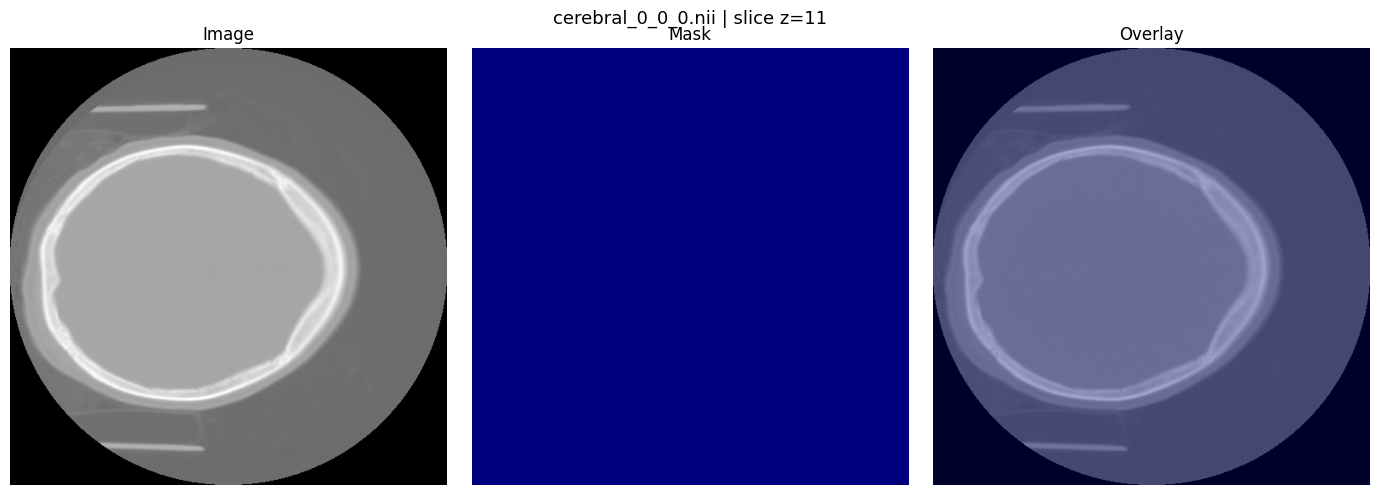

In [7]:
import matplotlib.pyplot as plt

s = train_pairs[0]
img = nib.load(s["image"]).get_fdata()
lab = nib.load(s["label"]).get_fdata()

z = img.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(img[:, :, z], cmap="gray")
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(lab[:, :, z], cmap="jet")
axes[1].set_title("Mask")
axes[1].axis("off")

axes[2].imshow(img[:, :, z], cmap="gray")
axes[2].imshow(lab[:, :, z], alpha=0.35, cmap="jet")
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.suptitle(f"{s['name']} | slice z={z}", fontsize=13)
plt.tight_layout()
plt.show()

## 5. setup Dataset (Slice-wise)

In [ ]:
import cv2
import torch
import numpy as np
import pandas as pd
import nibabel as nib
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── CUDA optimizations ──
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True   # Auto-tune convolution algorithms
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True


if device.type == 'cuda':
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU: {torch.cuda.get_device_name(0)}, VRAM: {vram_gb:.1f} GB")
    if vram_gb >= 14:       
        IMG_SIZE, BATCH_SIZE = 512, 4
    elif vram_gb >= 10:     # T4 (15GB), RTX 3060+
        IMG_SIZE, BATCH_SIZE = 384, 8
    else:                  
        IMG_SIZE, BATCH_SIZE = 256, 16
else:
    IMG_SIZE, BATCH_SIZE = 256, 8

MAX_EPOCHS  = 50
PATIENCE    = 8
VAL_RATIO   = 0.15
LR          = 1e-4
WEIGHT_DECAY = 1e-4
KEEP_EMPTY_RATIO = 0.3

print(f"→ IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}")


def normalize_volume(vol):
    
    vol = vol.astype(np.float32)
    lo, hi = np.percentile(vol, [0.5, 99.5])
    vol = np.clip((vol - lo) / (hi - lo + 1e-8), 0, 1)
    return vol.astype(np.float32)


def preextract_slices(pairs, img_size=256, keep_empty_ratio=0.15):
   
    items = []
    rng = np.random.default_rng(42)

    for p in tqdm(pairs, desc="Pre-extracting slices"):
        img = normalize_volume(nib.load(p["image"]).get_fdata())
        lab = (nib.load(p["label"]).get_fdata() > 0).astype(np.uint8)

        for z in range(img.shape[2]):
            mask_sum = int(lab[:, :, z].sum())
            keep = (mask_sum > 0) or (rng.random() < keep_empty_ratio)
            if not keep:
                continue

           
            img2d = cv2.resize(img[:, :, z], (img_size, img_size), interpolation=cv2.INTER_LINEAR)
            msk2d = cv2.resize(lab[:, :, z], (img_size, img_size), interpolation=cv2.INTER_NEAREST)

            items.append({
                "img": img2d,        # float32 (H, W) đã resize
                "msk": msk2d,        # uint8   (H, W) đã resize
                "name": p["name"],
                "z": z,
                "has_fg": int(mask_sum > 0),
            })

   
    total_bytes = sum(it["img"].nbytes + it["msk"].nbytes for it in items)
    print(f"  → {len(items)} slices, ~{total_bytes / 1024**2:.0f} MB in RAM")
    return items

Device: cuda
GPU: Tesla T4, VRAM: 14.6 GB
→ IMG_SIZE=512, BATCH_SIZE=4


### Split train volumes → train + val
Tách **theo volume** (không phải theo slice) để tránh data leakage.

In [ ]:
from sklearn.model_selection import train_test_split


train_vols, val_vols = train_test_split(
    train_pairs, test_size=VAL_RATIO, random_state=42
)
print(f"Train volumes: {len(train_vols)}, Val volumes: {len(val_vols)}")

print("\n── Pre-extracting train slices ──")
train_slices = preextract_slices(train_vols, img_size=IMG_SIZE, keep_empty_ratio=KEEP_EMPTY_RATIO)
print("\n── Pre-extracting val slices ──")
val_slices   = preextract_slices(val_vols,   img_size=IMG_SIZE, keep_empty_ratio=1.0)
print("\n── Pre-extracting test slices ──")
test_slices  = preextract_slices(test_pairs,  img_size=IMG_SIZE, keep_empty_ratio=1.0)

print(f"Train slices: {len(train_slices)}")
print(f"Val slices  : {len(val_slices)}")
print(f"Test slices : {len(test_slices)}")
print(f"Train positive slices: {sum(x['has_fg'] for x in train_slices)}")

Train volumes: 182, Val volumes: 33

── Pre-extracting train slices ──


Pre-extracting slices: 100%|██████████| 182/182 [01:46<00:00,  1.71it/s]


  → 2330 slices, ~2912 MB in RAM

── Pre-extracting val slices ──


Pre-extracting slices: 100%|██████████| 33/33 [00:19<00:00,  1.71it/s]


  → 759 slices, ~949 MB in RAM

── Pre-extracting test slices ──


Pre-extracting slices: 100%|██████████| 50/50 [00:29<00:00,  1.67it/s]

  → 1150 slices, ~1438 MB in RAM
Train slices: 2330
Val slices  : 759
Test slices : 1150
Train positive slices: 1529


## 6. Dataset & DataLoader

In [ ]:
class SliceSegDataset(Dataset):
    """
    Fast Dataset: slices đã pre-extract & resize sẵn trong RAM.
    __getitem__ chỉ làm augmentation + convert tensor → rất nhanh.
    """
    def __init__(self, items, augment=False):
        self.items = items
        self.augment = augment

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        img2d = item["img"].copy()   # float32 (H, W)
        msk2d = item["msk"].copy()   # uint8   (H, W)

       
        if self.augment:
            if np.random.rand() < 0.5:
                img2d = np.fliplr(img2d).copy()
                msk2d = np.fliplr(msk2d).copy()
            if np.random.rand() < 0.5:
                img2d = np.flipud(img2d).copy()
                msk2d = np.flipud(msk2d).copy()
           
            if np.random.rand() < 0.5:
                angle = np.random.uniform(-30, 30)
                h, w = img2d.shape[:2]
                M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
                img2d = cv2.warpAffine(img2d, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
                msk2d = cv2.warpAffine(msk2d, M, (w, h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT)
          
            if np.random.rand() < 0.4:
                scale = np.random.uniform(0.8, 1.2)
                h, w = img2d.shape[:2]
                M = cv2.getRotationMatrix2D((w / 2, h / 2), 0, scale)
                img2d = cv2.warpAffine(img2d, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
                msk2d = cv2.warpAffine(msk2d, M, (w, h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT)
            
            if np.random.rand() < 0.5:
                alpha = np.random.uniform(0.7, 1.3)
                beta  = np.random.uniform(-0.1, 0.1)
                img2d = np.clip(alpha * img2d + beta, 0, 1).astype(np.float32)
            
            if np.random.rand() < 0.3:
                noise = np.random.normal(0, 0.03, img2d.shape).astype(np.float32)
                img2d = np.clip(img2d + noise, 0, 1).astype(np.float32)
            
            if np.random.rand() < 0.2:
                ksize = np.random.choice([3, 5])
                img2d = cv2.GaussianBlur(img2d, (ksize, ksize), 0)

       
        img3 = np.stack([img2d, img2d, img2d], axis=0).astype(np.float32)
        msk1 = msk2d[None].astype(np.float32)

        return {
            "image": torch.from_numpy(img3),
            "mask": torch.from_numpy(msk1),
            "name": item["name"],
            "z": item["z"],
        }


train_ds = SliceSegDataset(train_slices, augment=True)
val_ds   = SliceSegDataset(val_slices,   augment=False)
test_ds  = SliceSegDataset(test_slices,  augment=False)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")

Train batches: 583
Val batches  : 190
Test batches : 288


## 7. Model: U-Net + ResNet50 Encoder

In [ ]:
model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None,
    decoder_use_batchnorm=True,
).to(device)


freeze_layers = ['encoder.conv1', 'encoder.bn1'] 
for name, param in model.named_parameters():
    if any(name.startswith(fl) for fl in freeze_layers):
        param.requires_grad = False
        frozen_count += 1

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total:,} total, {trainable:,} trainable, {frozen_count} layers frozen")


model.segmentation_head = torch.nn.Sequential(
    torch.nn.Dropout2d(p=0.3),
    *list(model.segmentation_head.children())
)
model = model.to(device)

# ── Combined loss ──
class CombinedLoss(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = smp.losses.DiceLoss(mode='binary', from_logits=True)
        self.focal = smp.losses.FocalLoss(mode='binary', alpha=0.25, gamma=2.0)

    def forward(self, pred, target):
        return self.dice(pred, target) + self.focal(pred, target)

loss_fn = CombinedLoss()

# ── Optimizer: 
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)

# ── Warmup 
WARMUP_EPOCHS = 3  

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.01, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS]
)
print(f"LR schedule: Warmup ({WARMUP_EPOCHS} epochs, 0.01×LR → LR) → Cosine Decay (→ 1e-6)")

# Mixed precision
use_amp = (device.type == "cuda")
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

print(f"AMP enabled: {use_amp}")

# torch.compile 
compiled = False
if hasattr(torch, 'compile'):
    try:
        model = torch.compile(model)
        compiled = True
        print("torch.compile: ENABLED")
    except Exception as e:
        print(f"torch.compile skipped: {e}")
else:
    print("torch.compile: not available (PyTorch < 2.0)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Parameters: 32,521,105 total, 32,511,569 trainable, 3 layers frozen
LR schedule: Warmup (3 epochs, 0.01×LR → LR) → Cosine Decay (→ 1e-6)
AMP enabled: True
torch.compile: ENABLED


## 8. Metrics Function

In [12]:
def compute_binary_metrics_from_logits(logits, target, threshold=0.5):
    """Tính TP/FP/FN/TN và các metric từ raw logits."""
    probs = torch.sigmoid(logits)
    pred = (probs > threshold)
    gt = (target > 0.5)

    tp = torch.logical_and(pred, gt).sum().item()
    fp = torch.logical_and(pred, ~gt).sum().item()
    fn = torch.logical_and(~pred, gt).sum().item()
    tn = torch.logical_and(~pred, ~gt).sum().item()

    eps = 1e-8
    dice      = (2 * tp) / (2 * tp + fp + fn + eps)
    iou       = tp / (tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    accuracy  = (tp + tn) / (tp + tn + fp + fn + eps)

    return {
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "accuracy": float(accuracy),
    }

## 9. Training Loop (với Early Stopping)

In [ ]:
history = {
    "epoch": [],
    "lr": [],
    "train_loss": [],
    "val_loss": [],
    "dice": [],
    "iou": [],
    "precision": [],
    "recall": [],
    "accuracy": [],
}

best_dice = -1.0
patience_counter = 0

import time
total_train_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start = time.time()
    # ── Train ──
    model.train()
    running_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS} [train]", leave=False):
        images = batch["image"].to(device, non_blocking=True)
        masks  = batch["mask"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(images)
            loss = loss_fn(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    train_loss = running_loss / max(1, len(train_loader))
    # scheduler.step() 

    # ── Validate ──
    model.eval()
    val_loss_sum = 0.0
    n_val = 0
    total_tp = total_fp = total_fn = total_tn = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS} [val]", leave=False):
            images = batch["image"].to(device, non_blocking=True)
            masks  = batch["mask"].to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(images)
                val_loss = loss_fn(logits, masks)

            val_loss_sum += val_loss.item()
            n_val += 1

            m = compute_binary_metrics_from_logits(logits, masks)
            total_tp += m["tp"]
            total_fp += m["fp"]
            total_fn += m["fn"]
            total_tn += m["tn"]

    # Aggregate validation metrics
    eps = 1e-8
    val_loss_mean = val_loss_sum / max(1, n_val)
    dice      = (2 * total_tp) / (2 * total_tp + total_fp + total_fn + eps)
    iou       = total_tp / (total_tp + total_fp + total_fn + eps)
    precision = total_tp / (total_tp + total_fp + eps)
    recall    = total_tp / (total_tp + total_fn + eps)
    accuracy  = (total_tp + total_tn) / (total_tp + total_tn + total_fp + total_fn + eps)
    current_lr = optimizer.param_groups[0]["lr"]
    epoch_time = time.time() - epoch_start

    # Log history
    history["epoch"].append(epoch)
    history["lr"].append(current_lr)
    history["train_loss"].append(float(train_loss))
    history["val_loss"].append(float(val_loss_mean))
    history["dice"].append(float(dice))
    history["iou"].append(float(iou))
    history["precision"].append(float(precision))
    history["recall"].append(float(recall))
    history["accuracy"].append(float(accuracy))

    print(
        f"Epoch {epoch:02d} | "
        f"lr={current_lr:.2e} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss_mean:.4f} | "
        f"dice={dice:.4f} | iou={iou:.4f} | "
        f"prec={precision:.4f} | rec={recall:.4f} | "
        f"acc={accuracy:.4f} | "
        f"{epoch_time:.0f}s"
    )

    # ── Save best & Early Stopping ──
    scheduler.step()  

    if dice > best_dice:
        best_dice = float(dice)
        patience_counter = 0
        # Save state_dict: strip _orig_mod. prefix nếu dùng torch.compile
        raw_model = model._orig_mod if hasattr(model, '_orig_mod') else model
        torch.save(raw_model.state_dict(), "best_resnet50_unet_binary.pth")
        print(f"  ↑ New best model saved! Dice = {best_dice:.4f}")
    else:
        patience_counter += 1
        print(f"  → No improvement ({patience_counter}/{PATIENCE})")

    if patience_counter >= PATIENCE:
        print(f"\n⚠ Early stopping triggered at epoch {epoch}. Best Dice = {best_dice:.4f}")
        break

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv("training_history_resnet50.csv", index=False)
print("\nSaved training_history_resnet50.csv")
print(f"Best validation Dice: {best_dice:.4f}")
print(f"Total training time: {(time.time() - total_train_start) / 60:.1f} minutes")

Epoch 1/50 [train]:   0%|          | 0/583 [00:00<?, ?it/s]W0316 10:30:57.404000 2439 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch 01 | lr=1.00e-06 | train_loss=1.2850 | val_loss=0.8452 | dice=0.0085 | iou=0.0043 | prec=0.0043 | rec=0.8380 | acc=0.2429 | 351s
  ↑ New best model saved! Dice = 0.0085


Epoch 02 | lr=3.40e-05 | train_loss=1.0321 | val_loss=0.5754 | dice=0.0000 | iou=0.0000 | prec=0.0000 | rec=0.0000 | acc=0.9959 | 98s
  → No improvement (1/8)


Epoch 03 | lr=6.70e-05 | train_loss=0.9912 | val_loss=0.5481 | dice=0.4529 | iou=0.2927 | prec=0.4299 | rec=0.4784 | acc=0.9955 | 97s
  ↑ New best model saved! Dice = 0.4529


Epoch 04 | lr=1.00e-04 | train_loss=0.9518 | val_loss=0.5083 | dice=0.3857 | iou=0.2389 | prec=0.2918 | rec=0.5685 | acc=0.9930 | 97s
  → No improvement (1/8)


...

Epoch 19 | lr=7.71e-05 | train_loss=0.4730 | val_loss=0.3547 | dice=0.4801 | iou=0.3159 | prec=0.4423 | rec=0.5249 | acc=0.9956 | 96s
  → No improvement (4/8)


Epoch 20 | lr=7.43e-05 | train_loss=0.4744 | val_loss=0.3223 | dice=0.6395 | iou=0.4700 | prec=0.6587 | rec=0.6213 | acc=0.9973 | 96s
  → No improvement (5/8)


Epoch 21 | lr=7.13e-05 | train_loss=0.4776 | val_loss=0.3313 | dice=0.6302 | iou=0.4601 | prec=0.6567 | rec=0.6058 | acc=0.9972 | 96s
  → No improvement (6/8)


Epoch 22 | lr=6.83e-05 | train_loss=0.4595 | val_loss=0.3426 | dice=0.5990 | iou=0.4276 | prec=0.5440 | rec=0.6665 | acc=0.9965 | 97s
  → No improvement (7/8)


Epoch 23 | lr=6.52e-05 | train_loss=0.4525 | val_loss=0.3378 | dice=0.6039 | iou=0.4326 | prec=0.5762 | rec=0.6345 | acc=0.9968 | 96s
  → No improvement (8/8)

⚠ Early stopping triggered at epoch 23. Best Dice = 0.6413

Saved training_history_resnet50.csv
Best validation Dice: 0.6413
Total training time: 41.3 minutes


## 10. Plot Training Curves

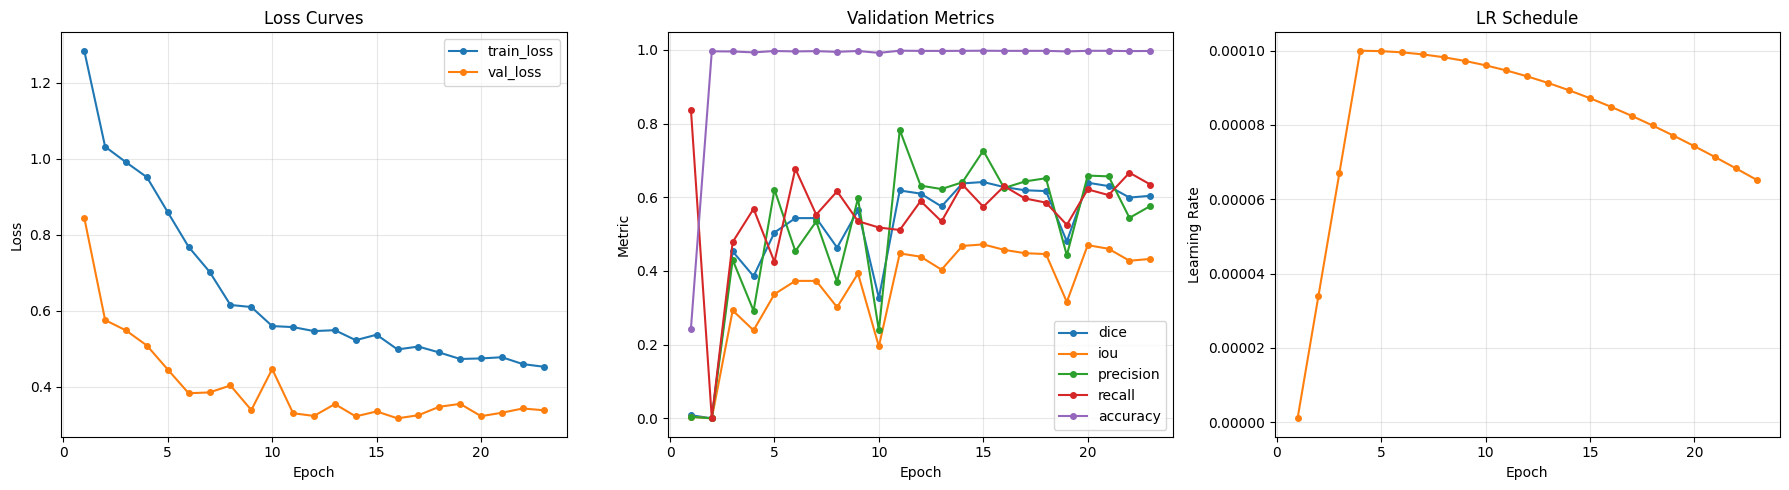

Saved training_curves_resnet50.png


In [14]:
import matplotlib.pyplot as plt

epochs_list = history["epoch"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(epochs_list, history["train_loss"], "o-", label="train_loss", markersize=4)
axes[0].plot(epochs_list, history["val_loss"], "o-", label="val_loss", markersize=4)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Segmentation metrics
for metric in ["dice", "iou", "precision", "recall", "accuracy"]:
    axes[1].plot(epochs_list, history[metric], "o-", label=metric, markersize=4)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Metric")
axes[1].set_title("Validation Metrics")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(epochs_list, history["lr"], "o-", color="tab:orange", markersize=4)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("LR Schedule")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves_resnet50.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved training_curves_resnet50.png")

## 11. Load Best Model

In [ ]:
model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None,
    decoder_use_batchnorm=True,
).to(device)


model.segmentation_head = torch.nn.Sequential(
    torch.nn.Dropout2d(p=0.3),
    *list(model.segmentation_head.children())
).to(device)

# Load weights 
state_dict = torch.load("best_resnet50_unet_binary.pth", map_location=device, weights_only=True)
state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)
model.eval()
print("Loaded best_resnet50_unet_binary.pth")

Loaded best_resnet50_unet_binary.pth


## 12. Inference Function (Volume-wise)

In [ ]:
def infer_volume_resnet50(nifti_path, img_size=256, threshold=0.5):
   
    nii = nib.load(nifti_path)
    vol = normalize_volume(nii.get_fdata())
    H, W, D = vol.shape

    pred_vol = np.zeros((H, W, D), dtype=np.uint8)

    with torch.no_grad():
        for z in range(D):
            img2d = vol[:, :, z]
            img_rs = cv2.resize(img2d, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
            img3 = np.stack([img_rs, img_rs, img_rs], axis=0).astype(np.float32)
            x = torch.from_numpy(img3[None]).to(device)

            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(x)

            prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
            pred_rs = (prob > threshold).astype(np.uint8)
            pred = cv2.resize(pred_rs, (W, H), interpolation=cv2.INTER_NEAREST)
            pred_vol[:, :, z] = pred

    return nii, vol, pred_vol

## 13. Inference trên 1 Volume Mẫu

In [17]:
sample = test_pairs[0]
nii, img, pred_vol = infer_volume_resnet50(sample["image"], img_size=IMG_SIZE)
gt = (nib.load(sample["label"]).get_fdata() > 0).astype(np.uint8)

print(f"Volume: {sample['name']}")
print(f"Pred shape: {pred_vol.shape}")
print(f"Pred unique: {np.unique(pred_vol)}")
print(f"GT voxels  : {gt.sum():,}")
print(f"Pred voxels: {pred_vol.sum():,}")

nib.save(
    nib.Nifti1Image(pred_vol.astype(np.uint8), affine=nii.affine, header=nii.header),
    "prediction_mask_resnet50.nii"
)
print("Saved prediction_mask_resnet50.nii")

Volume: cerebral_161_0_0.nii
Pred shape: (512, 512, 23)
Pred unique: [0 1]
GT voxels  : 119
Pred voxels: 1,996
Saved prediction_mask_resnet50.nii


## 14. Visualize Predictions (Confusion Map)

Slices shown: [5]


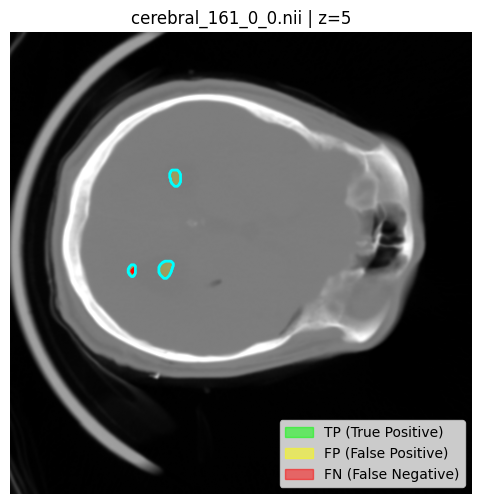

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

gt_bin = gt.astype(np.uint8)
pred_bin = pred_vol.astype(np.uint8)

H, W, D = gt_bin.shape
areas = gt_bin.reshape(-1, D).sum(axis=0)
top_z = np.argsort(-areas)[:3]
top_z = [int(z) for z in top_z if areas[z] > 0]

if not top_z:
    areas_pred = pred_bin.reshape(-1, D).sum(axis=0)
    top_z = [int(np.argmax(areas_pred))]

print("Slices shown:", top_z)


def show_one(z, show_confusion=True):
    im2d = img[:, :, z]
    gt2d = gt_bin[:, :, z]
    pr2d = pred_bin[:, :, z]

    tp = (pr2d == 1) & (gt2d == 1)
    fp = (pr2d == 1) & (gt2d == 0)
    fn = (pr2d == 0) & (gt2d == 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(im2d, cmap="gray")
    plt.title(f"{sample['name']} | z={z}")
    plt.axis("off")

    if show_confusion:
        overlay = np.zeros((H, W, 4), dtype=np.float32)
        overlay[tp] = [0.0, 1.0, 0.0, 0.25]  # Green = TP
        overlay[fp] = [1.0, 1.0, 0.0, 0.25]  # Yellow = FP
        overlay[fn] = [1.0, 0.0, 0.0, 0.25]  # Red = FN
        plt.imshow(overlay)

        handles = [
            mpatches.Patch(color=(0, 1, 0, 0.5), label="TP (True Positive)"),
            mpatches.Patch(color=(1, 1, 0, 0.5), label="FP (False Positive)"),
            mpatches.Patch(color=(1, 0, 0, 0.5), label="FN (False Negative)"),
        ]
        plt.legend(handles=handles, loc="lower right", framealpha=0.8)

    # Contour: Red = GT, Blue = Prediction
    if gt2d.any():
        plt.contour(gt2d.astype(float), levels=[0.5], colors="red", linewidths=2.0)
    if pr2d.any():
        plt.contour(pr2d.astype(float), levels=[0.5], colors="cyan", linewidths=2.0)

    plt.show()


for z in top_z:
    show_one(z, show_confusion=True)

## 15. Metrics cho Volume Mẫu

In [ ]:
def compute_np_metrics(pred_bin, gt_bin):
    
    pred_bool = pred_bin.astype(bool)
    gt_bool = gt_bin.astype(bool)

    tp = np.logical_and(pred_bool, gt_bool).sum()
    fp = np.logical_and(pred_bool, ~gt_bool).sum()
    fn = np.logical_and(~pred_bool, gt_bool).sum()
    tn = np.logical_and(~pred_bool, ~gt_bool).sum()

    eps = 1e-8
    dice      = (2 * tp) / (2 * tp + fp + fn + eps)
    iou       = tp / (tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    accuracy  = (tp + tn) / (tp + tn + fp + fn + eps)

    return {
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "accuracy": float(accuracy),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
    }

sample_metrics = compute_np_metrics(pred_bin, gt_bin)
print("Metrics for sample volume:")
for k, v in sample_metrics.items():
    print(f"  {k}: {v}")

Metrics for sample volume:
  dice: 0.05295508274206641
  iou: 0.02719766877111609
  precision: 0.028056112224308337
  recall: 0.47058823525457244
  accuracy: 0.9996677896250832
  tp: 56
  fp: 1940
  fn: 63
  tn: 6027253


## 16. Test Toàn Bộ Dataset + HD95

In [ ]:
import os
from surface_distance import metrics as sd_metrics


def hd95(pred_bin, gt_bin, spacing):
    
    pred_bool = pred_bin.astype(bool)
    gt_bool = gt_bin.astype(bool)

    if pred_bool.sum() == 0 and gt_bool.sum() == 0:
        return 0.0
    if pred_bool.sum() == 0 or gt_bool.sum() == 0:
        return None  

    surf = sd_metrics.compute_surface_distances(gt_bool, pred_bool, spacing_mm=spacing)
    return float(sd_metrics.compute_robust_hausdorff(surf, 95))


out_dir = "pred_test_nifti_resnet50"
os.makedirs(out_dir, exist_ok=True)

rows = []

for s in tqdm(test_pairs, desc="Testing all test volumes"):
    nii, vol, pred_vol = infer_volume_resnet50(s["image"], img_size=IMG_SIZE)
    gt = (nib.load(s["label"]).get_fdata() > 0).astype(np.uint8)

    m = compute_np_metrics(pred_vol, gt)
    m["name"]     = s["name"]
    m["gt_sum"]   = int(gt.sum())
    m["pred_sum"] = int(pred_vol.sum())

    spacing = tuple(float(x) for x in nii.header.get_zooms()[:3])
    m["hd95"] = hd95(pred_vol, gt, spacing)

    rows.append(m)

    # Save prediction NIfTI
    nib.save(
        nib.Nifti1Image(pred_vol.astype(np.uint8), affine=nii.affine, header=nii.header),
        os.path.join(out_dir, s["name"])
    )

results_df = pd.DataFrame(rows)
results_df.to_csv("test_metrics_resnet50_full.csv", index=False)
print("Saved test_metrics_resnet50_full.csv")
results_df

Testing all test volumes: 100%|██████████| 50/50 [01:57<00:00,  2.34s/it]

Saved test_metrics_resnet50_full.csv


,dice,iou,precision,recall,accuracy,tp,fp,fn,tn,name,gt_sum,pred_sum,hd95
0,0.052955,0.027198,0.028056,0.470588,0.999668,56,1940,63,6027253,cerebral_161_0_0.nii,119,1996,44.127850
1,0.754120,0.605291,0.820504,0.697674,0.993987,55599,12163,24093,5937457,cerebral_162_0_0.nii,79692,67762,11.978014
2,0.789514,0.652229,0.705916,0.895573,0.998150,20917,8714,2439,5997242,cerebral_163_0_0.nii,23356,29631,16.149907
3,0.158833,0.086268,0.803279,0.088129,0.999914,49,12,507,6028744,cerebral_164_0_0.nii,556,61,19.783500
4,0.750836,0.601071,0.938484,0.625725,0.999061,8528,559,5101,6015124,cerebral_165_0_0.nii,13629,9087,6.725608
5,0.859181,0.753126,0.866861,0.851636,0.997796,40537,6226,7062,5975487,cerebral_166_0_0.nii,47599,46763,51.757778
6,0.000000,0.000000,0.000000,0.000000,0.999899,0,107,504,6028701,cerebral_167_0_0.nii,504,107,85.815009
7,0.255475,0.146444,0.148182,0.925856,0.999058,974,5599,78,6022661,cerebral_168_0_0.nii,1052,6573,34.128352
8,0.748813,0.598482,0.713542,0.787752,0.996384,32494,13045,8755,5975018,cerebral_169_0_0.nii,41249,45539,22.236898
9,0.000000,0.000000,0.000000,0.000000,0.999030,0,1592,4257,6023463,cerebral_170_0_0.nii,4257,1592,118.482890


## 17. Thống kê Tổng hợp

In [21]:
def summarize_col(series):
    vals = series.dropna().values
    if len(vals) == 0:
        return {"mean": None, "std": None, "median": None, "min": None, "max": None}
    return {
        "mean":   float(np.mean(vals)),
        "std":    float(np.std(vals)),
        "median": float(np.median(vals)),
        "min":    float(np.min(vals)),
        "max":    float(np.max(vals)),
    }

metrics_to_summarize = ["dice", "iou", "precision", "recall", "accuracy", "hd95"]
summary = {m: summarize_col(results_df[m]) for m in metrics_to_summarize}
summary_df = pd.DataFrame(summary).T
print("\n=== Test Set Summary ===")
summary_df


=== Test Set Summary ===


,mean,std,median,min,max
dice,0.443914,0.322509,0.549414,0.000000,0.917181
iou,0.342079,0.276730,0.378784,0.000000,0.847031
precision,0.500381,0.337382,0.638256,0.000000,0.938484
recall,0.479868,0.350073,0.537897,0.000000,0.977980
accuracy,0.998062,0.001957,0.998698,0.992433,0.999998
hd95,43.593145,30.822867,39.316591,4.826077,125.893897


### Box Plot: Phân phối Metrics trên Test Set

/tmp/ipykernel_2439/3004322477.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(hd95_vals, labels=["HD95"])


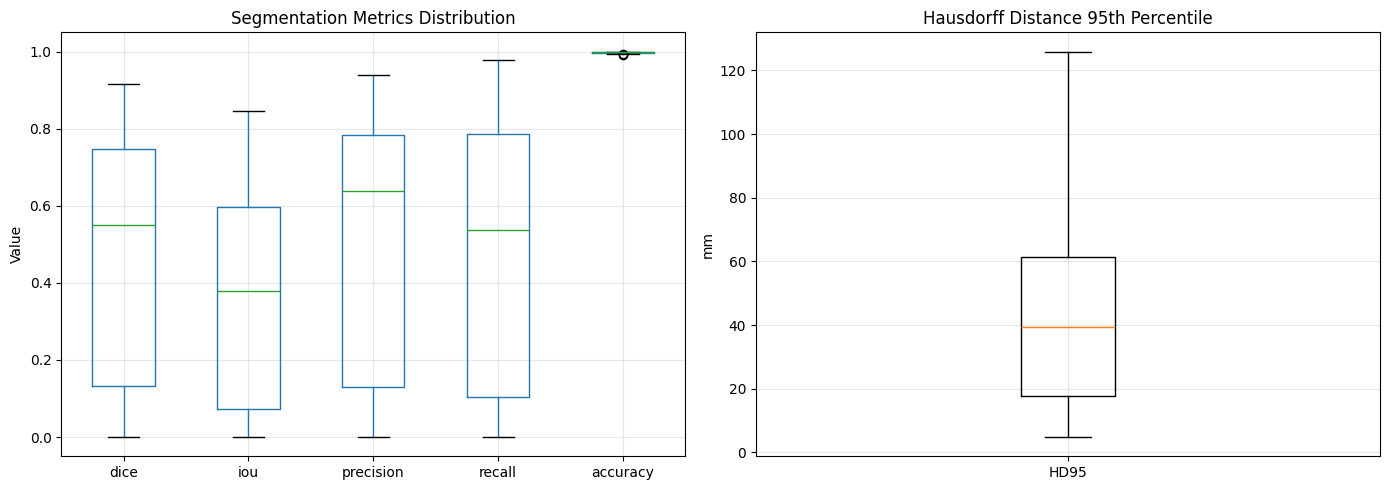

Saved test_metrics_boxplot_resnet50.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segmentation metrics
seg_cols = ["dice", "iou", "precision", "recall", "accuracy"]
results_df[seg_cols].boxplot(ax=axes[0])
axes[0].set_title("Segmentation Metrics Distribution")
axes[0].set_ylabel("Value")
axes[0].grid(True, alpha=0.3)

# HD95
hd95_vals = results_df["hd95"].dropna()
if len(hd95_vals) > 0:
    axes[1].boxplot(hd95_vals, labels=["HD95"])
    axes[1].set_title("Hausdorff Distance 95th Percentile")
    axes[1].set_ylabel("mm")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "No valid HD95 values", ha="center", va="center")

plt.tight_layout()
plt.savefig("test_metrics_boxplot_resnet50.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved test_metrics_boxplot_resnet50.png")

## 18. Save Predictions (Zip)

In [23]:
import zipfile

zip_path = "pred_test_nifti_resnet50.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for fn in os.listdir(out_dir):
        zf.write(os.path.join(out_dir, fn), arcname=fn)

print(f"Saved: {zip_path} ({os.path.getsize(zip_path) / 1024 / 1024:.1f} MB)")

Saved: pred_test_nifti_resnet50.zip (2.4 MB)


## 19. 3D Visualization (Plotly)

In [ ]:
from skimage import measure
import plotly.graph_objects as go

best_idx = int(results_df["dice"].idxmax())
name = results_df.loc[best_idx, "name"]
best_dice_val = results_df.loc[best_idx, "dice"]
print(f"Visualizing: {name} (Dice = {best_dice_val:.4f})")

s = next(x for x in test_pairs if x["name"] == name)
nii = nib.load(s["image"])
gt = (nib.load(s["label"]).get_fdata() > 0).astype(np.uint8)
pred = nib.load(os.path.join(out_dir, name)).get_fdata().astype(np.uint8)

sx, sy, sz = nii.header.get_zooms()[:3]


def mesh_from_mask(mask, level=0.5):
    """Tạo 3D mesh từ binary mask sử dụng Marching Cubes."""
    if mask.sum() == 0:
        return None, None
    verts, faces, _, _ = measure.marching_cubes(mask, level=level)
    # Scale theo voxel spacing
    verts = np.stack([verts[:, 0] * sx, verts[:, 1] * sy, verts[:, 2] * sz], axis=1)
    return verts, faces


gt_verts, gt_faces = mesh_from_mask(gt)
pr_verts, pr_faces = mesh_from_mask(pred)

fig = go.Figure()

if gt_verts is not None:
    fig.add_trace(go.Mesh3d(
        x=gt_verts[:, 0], y=gt_verts[:, 1], z=gt_verts[:, 2],
        i=gt_faces[:, 0], j=gt_faces[:, 1], k=gt_faces[:, 2],
        opacity=0.35, name="Ground Truth", color="red",
        showlegend=True,
    ))

if pr_verts is not None:
    fig.add_trace(go.Mesh3d(
        x=pr_verts[:, 0], y=pr_verts[:, 1], z=pr_verts[:, 2],
        i=pr_faces[:, 0], j=pr_faces[:, 1], k=pr_faces[:, 2],
        opacity=0.35, name="Prediction", color="blue",
        showlegend=True,
    ))

fig.update_layout(
    title=f"3D Hemorrhage Mesh: {name} (Dice={best_dice_val:.4f})",
    scene=dict(aspectmode="data"),
    legend=dict(x=0.02, y=0.98),
    width=800, height=600,
)
fig.show()

Visualizing: cerebral_185_0_0.nii (Dice = 0.9172)


## 20. Download Files (Colab)

In [ ]:

from google.colab import files

files.download("best_resnet50_unet_binary.pth")
files.download("training_history_resnet50.csv")
files.download("training_curves_resnet50.png")
files.download("test_metrics_resnet50_full.csv")
files.download("test_metrics_boxplot_resnet50.png")
files.download("pred_test_nifti_resnet50.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>